# Cybersecurity Threat Analysis

Objective:
Analyze global cybersecurity incidents to identify attack patterns, financial impact, affected industries, and security trends.

Tools:
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- SciPy

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
threats=pd.read_csv("/content/CYBER.csv")

In [4]:
threats.columns

Index(['Country', 'Year', 'Attack Type', 'Target Industry',
       'Financial Loss (in Million $)', 'Number of Affected Users',
       'Attack Source', 'Security Vulnerability Type',
       'Defense Mechanism Used', 'Incident Resolution Time (in Hours)'],
      dtype='object')

In [ ]:
threats.isnull().sum()

,0
Country,0
Year,0
Attack Type,0
Target Industry,0
Financial Loss (in Million $),0
Number of Affected Users,0
Attack Source,0
Security Vulnerability Type,0
Defense Mechanism Used,0
Incident Resolution Time (in Hours),0


In [ ]:
threats.drop_duplicates(keep='first',inplace=True)

In [ ]:
threats.shape

(3000, 10)

UNIVARIATE ANALYSIS:

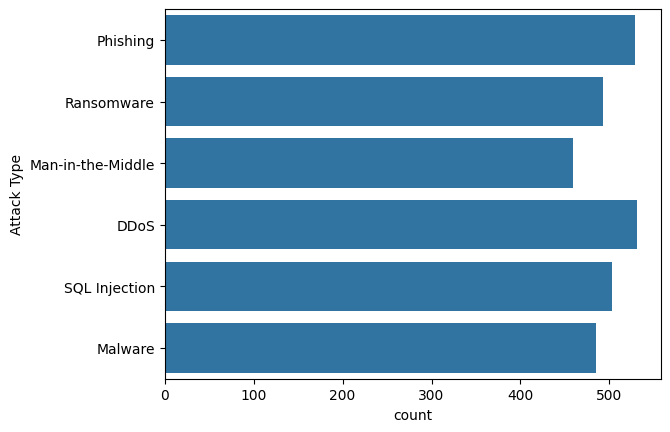

In [ ]:
sns.countplot(y="Attack Type",data=threats)
plt.show()

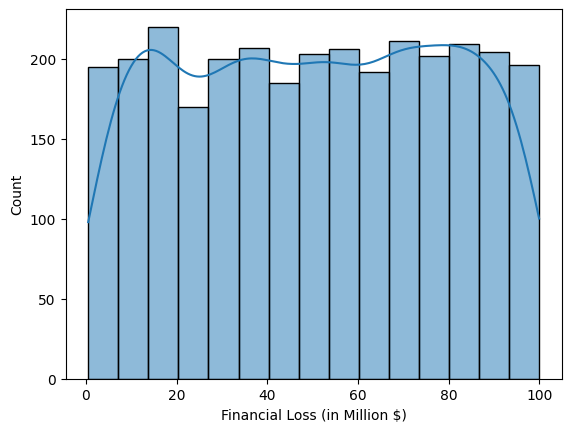

In [ ]:
sns.histplot(threats["Financial Loss (in Million $)"],kde=True)
plt.show()

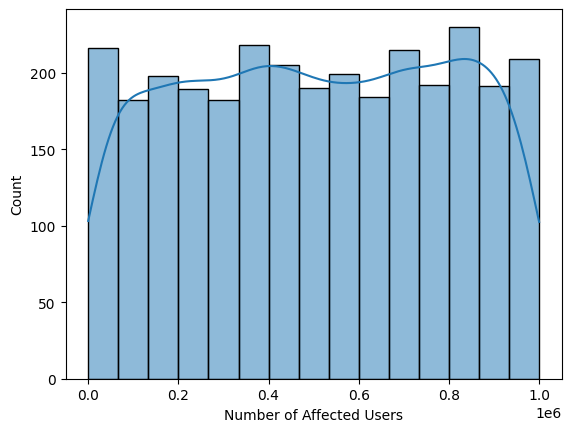

In [ ]:
sns.histplot(threats["Number of Affected Users"],kde=True)
plt.show()

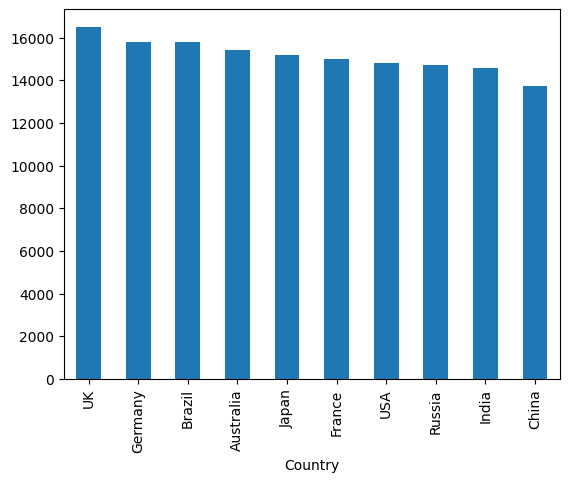

In [ ]:
country_analysis=threats.groupby("Country")["Financial Loss (in Million $)"].sum().sort_values(ascending=False).head(10).plot(kind="bar")
plt.show()

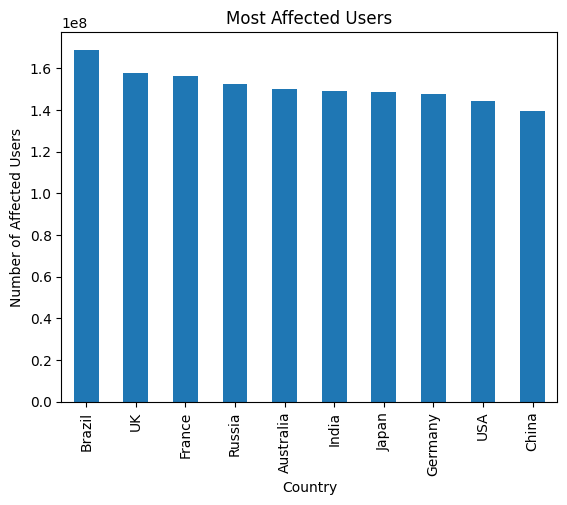

In [8]:
most_affected_user=threats.groupby("Country")["Number of Affected Users"].sum().sort_values(ascending=False).head(10).plot(kind="bar")

plt.title("Most Affected Users")
plt.xlabel("Country")
plt.ylabel("Number of Affected Users")
plt.show()

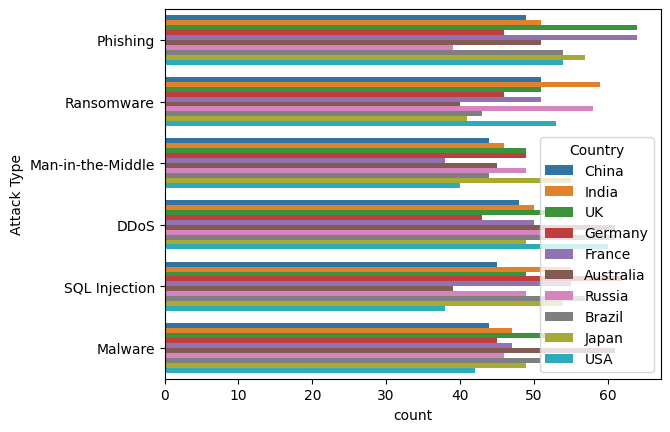

In [11]:
sns.countplot(y="Attack Type",data=threats,hue="Country")
plt.show()


([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Education'),
  Text(1, 0, 'Retail'),
  Text(2, 0, 'IT'),
  Text(3, 0, 'Telecommunications'),
  Text(4, 0, 'Government'),
  Text(5, 0, 'Banking'),
  Text(6, 0, 'Healthcare')])

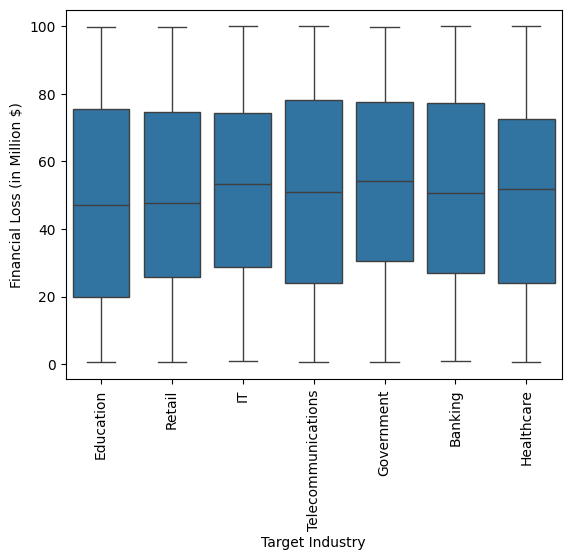

In [16]:
sns.boxplot(
    x="Target Industry",
    y="Financial Loss (in Million $)",
    data=threats
)
plt.xticks(rotation=90)

<Axes: xlabel='Attack Type'>

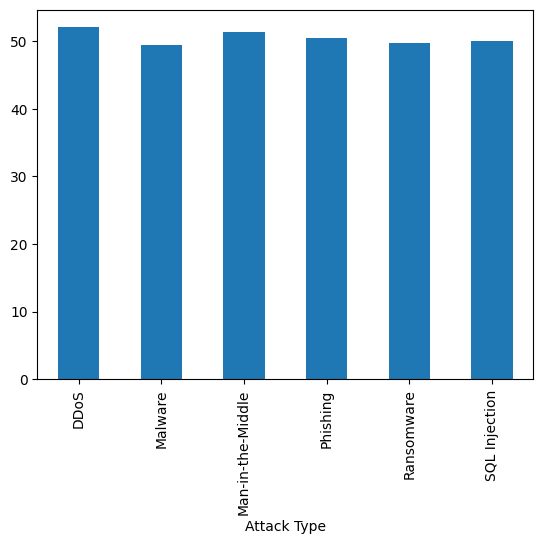

In [23]:
attack_loss = threats.groupby(
    "Attack Type"
)["Financial Loss (in Million $)"].mean()

attack_loss.plot(kind="bar")

<Axes: xlabel='Attack Type'>

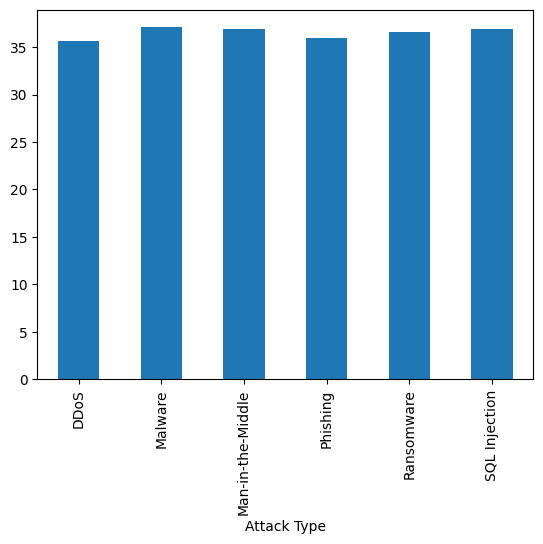

In [25]:
resolution =threats.groupby(
    "Attack Type"
)["Incident Resolution Time (in Hours)"].mean()

resolution.plot(kind="bar")

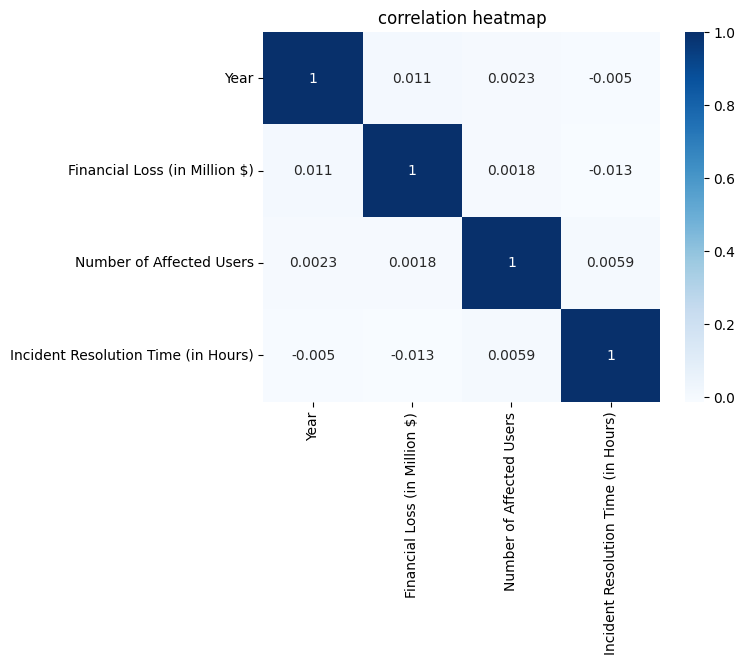

In [36]:
correlation=threats.corr(numeric_only=True)
correlation
sns.heatmap(correlation,annot=True,cmap="Blues")
plt.title("correlation heatmap")
plt.show()

In [43]:
from scipy.stats import shapiro
stat,p = shapiro(
    threats["Financial Loss (in Million $)"]
)

print("statistics=",stat)
print("p-value=",p)

statistics= 0.9539873659046594
p-value= 9.265928995142903e-30


In [44]:
from scipy.stats import ttest_ind

In [47]:
ransomware = threats[
    threats["Attack Type"]=="Ransomware"
]["Financial Loss (in Million $)"]

phishing = threats[
    threats["Attack Type"]=="Phishing"
]["Financial Loss (in Million $)"]

In [48]:
stat,p=ttest_ind(ransomware,phishing)
print("statistics=",stat)
print("p-value=",p)

statistics= -0.4477560501925057
p-value= 0.6544243433007667


In [49]:
alpha = 0.05

if p < alpha:
    print("Reject H₀")
    print("There is a significant difference in average financial loss between Ransomware and Phishing attacks.")
else:
    print("Fail to Reject H₀")
    print("There is no significant difference in average financial loss between Ransomware and Phishing attacks.")

Fail to Reject H₀
There is no significant difference in average financial loss between Ransomware and Phishing attacks.


In [52]:
print("Average Ransomware Loss =", ransomware.mean())
print("Average Phishing Loss =", phishing.mean())

print("Ransomware Count =", len(ransomware))
print("Phishing Count =", len(phishing))

Average Ransomware Loss = 49.65379310344827
Average Phishing Loss = 50.45990548204159
Ransomware Count = 493
Phishing Count = 529
